In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.env.pricing_env import DynamicPricingEnv
from src.agents.baseline import FixedPriceAgent

In [2]:
agent = FixedPriceAgent(price_index=2)

In [3]:
env = DynamicPricingEnv()

state, info = env.reset()

terminated = False

while not terminated:

    action = agent.select_action(state)

    state, reward, terminated, truncated, info = env.step(action)

In [4]:
print(f"Revenue: {env.total_revenue}")
print(f"Remaining Inventory: {env.inventory}")

Revenue: 1440
Remaining Inventory: 88


In [5]:
revenues = []

for _ in range(100):

    env = DynamicPricingEnv()

    state, info = env.reset()

    agent = FixedPriceAgent(price_index=2)

    terminated = False

    while not terminated:

        action = agent.select_action(state)

        state, reward, terminated, truncated, info = env.step(action)

    revenues.append(env.total_revenue)

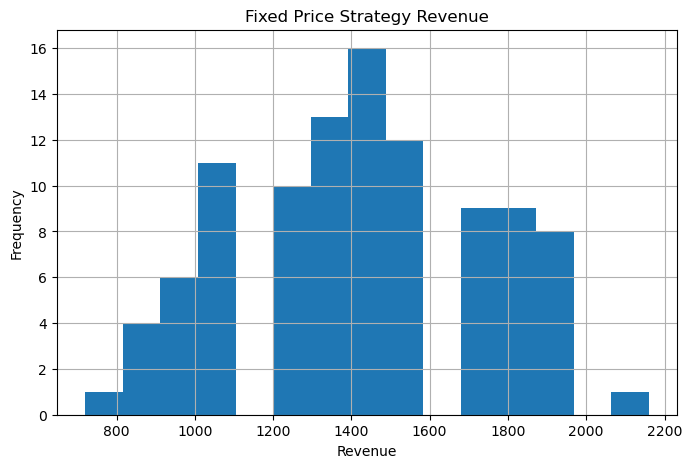

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(revenues, bins=15)

plt.title("Fixed Price Strategy Revenue")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()